Mock Mental Health Trends (First 10 Rows):
   Year State AgeGroup ActivityLevel  AvgDistressScore
0  2015   NSW    18-29           Low              30.5
1  2015   NSW    18-29        Medium              29.4
2  2015   NSW    18-29          High              29.6
3  2015   NSW    30-44           Low              31.6
4  2015   NSW    30-44        Medium              29.4
5  2015   NSW    30-44          High              28.9
6  2015   NSW    45-59           Low              31.8
7  2015   NSW    45-59        Medium              30.5
8  2015   NSW    45-59          High              28.7
9  2015   NSW      60+           Low              30.8


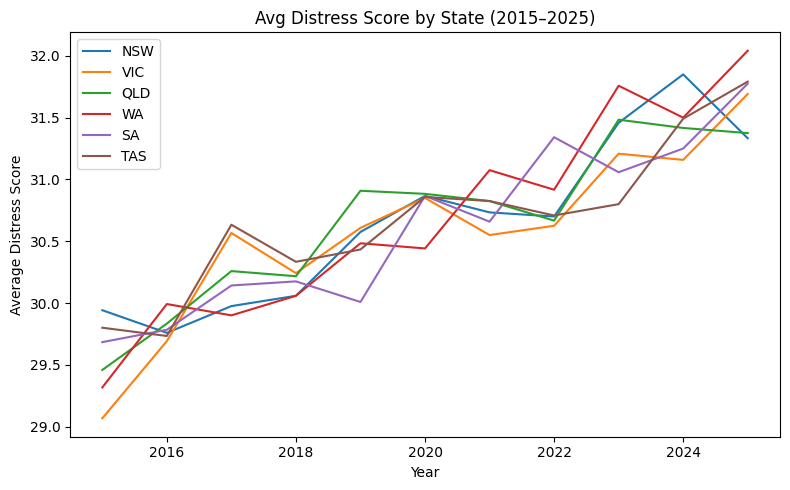

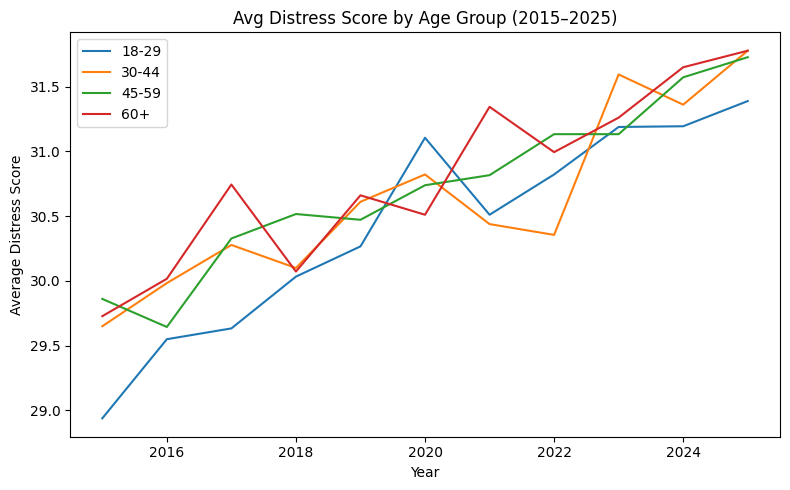

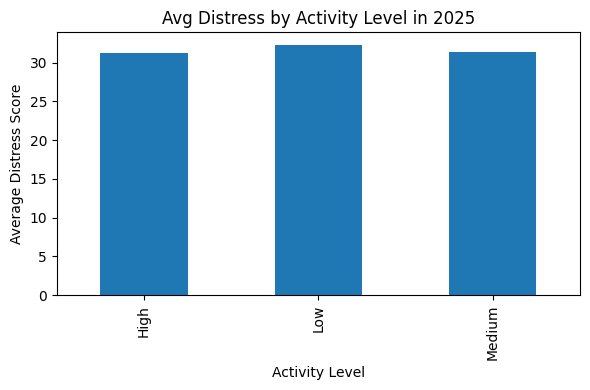

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate mock mental health trends data
np.random.seed(42)
years = np.arange(2015, 2026)
states = ['NSW', 'VIC', 'QLD', 'WA', 'SA', 'TAS']
age_groups = ['18-29', '30-44', '45-59', '60+']
activity_levels = ['Low', 'Medium', 'High']

# Create a cartesian product of all categories and years
records = []
for year in years:
    for state in states:
        for age in age_groups:
            for activity in activity_levels:
                # Simulate average distress score (10-50 scale)
                base = 30 - (0.5 * activity_levels.index(activity))  # more activity lowers distress
                age_adj = 0.1 * age_groups.index(age)  # older groups slightly higher distress
                trend = (year - 2015) * 0.2  # slight upward trend
                score = base + age_adj + trend + np.random.normal(0, 1)
                records.append({
                    'Year': year,
                    'State': state,
                    'AgeGroup': age,
                    'ActivityLevel': activity,
                    'AvgDistressScore': round(score, 1)
                })

df = pd.DataFrame(records)
df.to_csv('mental_health_trends.csv', index=False)  # Save for later use

# 2. Display a sample of the data
print("Mock Mental Health Trends (First 10 Rows):")
print(df.head(10))

# 3. Plot trends by state
plt.figure(figsize=(8, 5))
for state in states:
    subset = df[df['State'] == state].groupby('Year')['AvgDistressScore'].mean()
    plt.plot(years, subset, label=state)
plt.title('Avg Distress Score by State (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Average Distress Score')
plt.legend()
plt.tight_layout()
plt.show()

# 4. Plot trends by age group
plt.figure(figsize=(8, 5))
for age in age_groups:
    subset = df[df['AgeGroup'] == age].groupby('Year')['AvgDistressScore'].mean()
    plt.plot(years, subset, label=age)
plt.title('Avg Distress Score by Age Group (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Average Distress Score')
plt.legend()
plt.tight_layout()
plt.show()

# 5. Plot bar chart for activity level in latest year
latest = df[df['Year'] == df['Year'].max()]
activity_avg = latest.groupby('ActivityLevel')['AvgDistressScore'].mean()
plt.figure(figsize=(6, 4))
activity_avg.plot(kind='bar')
plt.title(f'Avg Distress by Activity Level in {df["Year"].max()}')
plt.xlabel('Activity Level')
plt.ylabel('Average Distress Score')
plt.tight_layout()
plt.show()

In [15]:
# 6. Sample pandas filtering & grouping logic
# a) Filter for NSW and calculate the yearly average distress
nsw_avg = df[df['State']=='NSW'].groupby('Year')['AvgDistressScore'].mean()
print("NSW Average Distress by Year:\n", nsw_avg, "\n")

# b) Get data for ages 18-29 with High activity
young_high = df[(df['AgeGroup']=='18-29') & (df['ActivityLevel']=='High')]
print("Records for 18-29 with High Activity:\n", young_high.head(), "\n")

# c) Sort all records by distress descending and show top 5
top_distress = df.sort_values('AvgDistressScore', ascending=False).head()
print("Top 5 Highest Distress Records:\n", top_distress)


NSW Average Distress by Year:
 Year
2015    29.941667
2016    29.758333
2017    29.975000
2018    30.058333
2019    30.575000
2020    30.866667
2021    30.733333
2022    30.700000
2023    31.458333
2024    31.850000
2025    31.333333
Name: AvgDistressScore, dtype: float64 

Records for 18-29 with High Activity:
     Year State AgeGroup ActivityLevel  AvgDistressScore
2   2015   NSW    18-29          High              29.6
14  2015   VIC    18-29          High              27.3
26  2015   QLD    18-29          High              27.8
38  2015    WA    18-29          High              27.7
50  2015    SA    18-29          High              29.3 

Top 5 Highest Distress Records:
      Year State AgeGroup ActivityLevel  AvgDistressScore
762  2025    WA    45-59           Low              34.8
654  2024   NSW    45-59           Low              34.6
478  2021    WA      60+        Medium              34.1
755  2025   QLD      60+          High              33.9
738  2025   VIC    45-59      